In [14]:
#Imports

import numpy as np
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
import matplotlib.pyplot as plt
import matplotlib
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
import warnings
warnings.filterwarnings("ignore")
from simpeg import (
    maps, data, data_misfit, regularization,
    optimization, inverse_problem, inversion, directives,utils,
)
from ipywidgets import widgets, interact
from pathlib import Path
from mtpy.core.mt_collection import MTCollection
mtc = MTCollection()
import mtpy as mt
import utm
import matplotlib.gridspec as gridspec


#Solver for Mac
from pymatsolver import Mumps

matplotlib.rcParams['font.size'] = 14


### Geological Figure of Uranium Ore Body

![My Image](Geological_Figures.png)

### Defining Properties and Plotting Layer Model

Text(0.5, 1.0, 'Depth vs. Sigma')

<Figure size 1000x500 with 0 Axes>

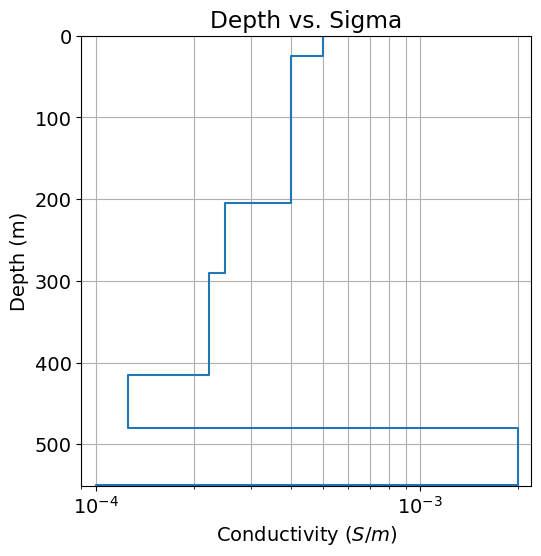

In [2]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 65,70,1]) #Thicknesses were obtained from Tuncer, pg. 16
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,500,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data


#Plotting 1D Layer Model for visualization
fig = plt.figure(figsize=(10, 5))
ax1 = plot_1d_layer_model(layer_thicknesses, sigma) # figure has base value at log plot
ax1.grid(which="both")
ax1.set_xlabel(r"Conductivity ($S/m$)")
ax1.set_title('Depth vs. Sigma')


### Opening Data Files to obtain RX locations

26:03:30T22:02:52 | WARNING | line:590 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>
26:03:30T22:02:52 | WARNING | line:590 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>
26:03:30T22:02:52 | WARNING | line:405 |mtpy.core.mt_collection | add_tf | If you are adding multiple transfer functions, suggest making a list of transfer functions first then adding the list using mt_collection.add_tf([list_of_tfs]). Otherwise adding transfer functions one by one will be slow.
26:03:30T22:02:52 | INFO | line:591 |mtpy.core.mt_collection | _from_mt_object | added grid.30404N
26:03:30T22:02:53 | WARNING | line:590 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>
26:0

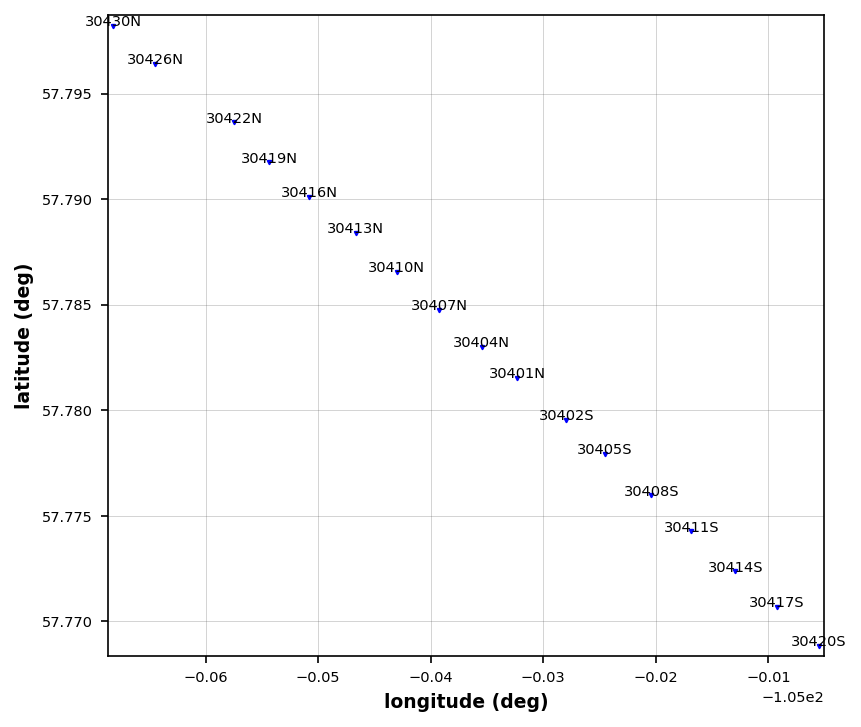

26:03:30T22:03:01 | INFO | line:1035 |mth5.mth5 | close_mth5 | Flushing and closing /Users/emilianohdz/EOSC454/Project/EOSC454-Inversion-Project-2026/test_collection100.h5
True grid.30401N
True grid.30402S
True grid.30404N
True grid.30405S
True grid.30407N
True grid.30408S
True grid.30410N
True grid.30411S
True grid.30413N
True grid.30414S
True grid.30416N
True grid.30417S
True grid.30419N
True grid.30420S
True grid.30422N
True grid.30426N
False grid.30430N


In [3]:
#Opening 304 line file
directory_path = Path("304")
mtc = mt.MTCollection()
mtc.open_collection(Path().cwd().joinpath("test_collection100.h5"))

for file_path in directory_path.iterdir():
    if file_path.is_file():
        mt_object = mt.MT()
        mt_object.read(file_path)
        mt_object.survey_metadata.id = "grid"
        mtc.add_tf(mt_object)

mtc.working_dataframe = mtc.master_dataframe.loc[mtc.master_dataframe.survey == "grid"]
mtc.working_dataframe

station_plot = mtc.plot_stations(pad=0.0005)

mtd = mtc.to_mt_data()
mtc.close_collection()

# collect the data into a nice list and convert the data and locations
_impUnitEDI2SI = 4 * np.pi * 1e-4

#Initializing location and elevation lists
rx_locs = []
rx_locs_tipper = []
elevation = []
elevation_tipper = []

for key in mtd.keys():
    print(mtd[key].has_tipper(), key)
    rx_locs += [utm.from_latlon(mtd[key].latitude, mtd[key].longitude)[:2]]
    elevation += [mtd[key].elevation]

    if mtd[key].has_tipper():
        rx_locs_tipper += [utm.from_latlon(mtd[key].latitude, mtd[key].longitude)[:2]]
        elevation_tipper += [mtd[key].elevation]

### Setting up 1D MT Simulation

In [4]:
#Survey Properties
frequencies = np.r_[7.68*10**3, 5.12*10**3, 3.84*10**3, 1.28*10**3,
    9.59*10**2, 6.4*10**2, 4.64*10**2, 3.36*10**2, 2.4*10**2, 1.77*10**2, 1.28*10**2,
    9.699*10**1,8.1*10**1,7.1*10**1,6.1*10**1,5.1*10**1,4.1*10**1,3.275*10**1,2.225*10**1,1.512*10**1,1.025*10**1,
    6.937,4.875]  # frequencies in Hz # Obtained from Cameco Data, Line 304

#Setting up mesh
mesh = TensorMesh([layer_thicknesses], origin="0")

############

#wire_map = maps.Wires(("sigma", mesh.nC), ("t", mesh.nC - 1)) # Mapping class for organizing multiple parameter types into a single model. m = [sigma | t]
sigma_map = maps.ExpMap(nP=mesh.nC)# * wire_map.sigma # Extracting sigma from wire_map
#layer_map = maps.ExpMap(nP=mesh.nC - 1) * wire_map.t # Extracting layers t from wire_map


model_mapping = maps.IdentityMap(nP=len(sigma))

#Setting up RX locations 
rx_loc_single = np.array([[1.0]])
receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="apparent_resistivity"),# Using RX_loc for first receiver 1/17
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="phase"),
]

source_list = []
for freq in frequencies:
    source_list.append(nsem.sources.Planewave(receivers_list, freq)) # Setting sources as plane waves at each specified frequencies 

survey = nsem.survey.Survey(source_list) #Creating survey object with given sources form source_list

simulation = nsem.Simulation1DElectricField(mesh,
    survey=survey, 
    sigmaMap=sigma_map,
    solver = Mumps)

true_model = np.log(sigma)

dpred = simulation.dpred(true_model)


In [5]:
dpred

array([ 4.22171659e+05, -1.79978285e+02,  6.33257438e+05, -1.79985524e+02,
        8.44343227e+05, -1.79989143e+02,  2.53302960e+06, -1.79996381e+02,
        3.38089456e+06, -1.79997288e+02,  5.06605919e+06, -1.79998190e+02,
        6.98766784e+06, -1.79998688e+02,  9.64963654e+06, -1.79999050e+02,
        1.35094912e+07, -1.79999321e+02,  1.83179541e+07, -1.79999500e+02,
        2.53302959e+07, -1.79999638e+02,  3.34289914e+07, -1.79999726e+02,
        4.00281219e+07, -1.79999771e+02,  4.56658856e+07, -1.79999799e+02,
        5.31520963e+07, -1.79999828e+02,  6.35740760e+07, -1.79999856e+02,
        7.90799482e+07, -1.79999884e+02,  9.90008512e+07, -1.79999907e+02,
        1.45720354e+08, -1.79999937e+02,  2.14436368e+08, -1.79999957e+02,
        3.16319793e+08, -1.79999971e+02,  4.67389055e+08, -1.79999980e+02,
        6.65082641e+08, -1.79999986e+02])

### Test Inversion

In [6]:
#Setting geometry parameters.
dz = 25 # First layer depth
n_layer = 6 # Number of Layers
z_factor = 2.3 # Layer depth increase factor

#layer_thicknesses_inv = dz * z_factor**np.arange(n_layer-1) # Layer thicknesses
layer_thicknesses_inv=  np.array([25, 180, 85, 125, 135]) # Need to ask if it is ok to use predetermined thicknesses (Could be too much prior knowledge)??? # Including the halfspace...

In [7]:
#Defining inversion function
def run_smooth_inversion(
    dobs,
    standard_deviation,
    rho_0,
    rho_ref,
    maxIter=10,
    maxIterCG=30,
    maxIterLS=30,
    alpha_s=1e-10,
    alpha_z=1,
    beta0_ratio=1,
    coolingFactor=2,
    coolingRate=1,
    chi_factor=1,
    p_s=0, 
    p_z=0,
    
):
    mesh_inv = TensorMesh([(np.r_[layer_thicknesses_inv, layer_thicknesses_inv[-1]])], "N")
    receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="apparent_resistivity"),
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="phase"),
    ]

    source_list = []
    for freq in frequencies:
        source_list.append(nsem.sources.Planewave(receivers_list, freq))

    survey = nsem.survey.Survey(source_list)

    sigma_map = maps.ExpMap(nP=len(layer_thicknesses_inv)+1)
    simulation = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey, 
        sigmaMap=sigma_map,
        thicknesses=layer_thicknesses_inv,
    )
    # Define the data 
    data_object = data.Data(survey, dobs=dobs, standard_deviation=standard_deviation)    
    
    # Initial model
    m0 = np.ones(len(layer_thicknesses_inv)+1) * np.log(1./rho_0)
    
    # Reference model
    mref = np.ones(len(layer_thicknesses_inv)+1) * np.log(1./rho_ref)    
    
    dmis = data_misfit.L2DataMisfit(simulation=simulation, data=data_object)

    # Define the regularization (model objective function)
    reg = regularization.Sparse(
        mesh_inv, alpha_s=alpha_s, alpha_x=alpha_z, 
        reference_model=mref,
        reference_model_in_smooth=False,
        mapping=maps.IdentityMap(mesh=mesh_inv),
    )

    # Define how the optimization problem is solved. Here we will use an inexact
    # Gauss-Newton approach that employs the conjugate gradient solver.
    opt = optimization.InexactGaussNewton(
    maxIter=maxIter,
    maxIterCG=maxIterCG,
    maxIterLS=maxIterLS,
    )


    # Define the inverse problem
    inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

    #######################################################################
    # Define Inversion Directives
    # ---------------------------
    #
    # Here we define any directives that are carried out during the inversion. This
    # includes the cooling schedule for the trade-off parameter (beta), stopping
    # criteria for the inversion and saving inversion results at each iteration.
    #

    # Defining a starting value for the trade-off parameter (beta) between the data
    # misfit and the regularization.
    starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=beta0_ratio)

    # Set the rate of reduction in trade-off parameter (beta) each time the
    # the inverse problem is solved. And set the number of Gauss-Newton iterations
    # for each trade-off paramter value.
    beta_schedule = directives.BetaSchedule(coolingFactor=coolingFactor, coolingRate=coolingRate)
    save_dictionary = directives.SaveOutputDictEveryIteration()
    save_dictionary.outDict = {}
    # Setting a stopping criteria for the inversion.
    target_misfit = directives.TargetMisfit(chifact=chi_factor)
    precond = directives.UpdatePreconditioner()

    # The directives are defined as a list.
    directives_list = [
        precond,
        starting_beta,
        beta_schedule,
        target_misfit,
        save_dictionary
    ]

    #####################################################################
    # Running the Inversion
    # ---------------------
    #
    # To define the inversion object, we need to define the inversion problem and
    # the set of directives. We can then run the inversion.
    #

    # Here we combine the inverse problem and the set of directives
    inv = inversion.BaseInversion(inv_prob, directives_list)

    # Run the inversion
    recovered_model = inv.run(m0)    
    
    return recovered_model, save_dictionary.outDict

In [8]:
relative_error_rho = 0.1
floor_phase = 1.
rho_app = dpred.reshape((len(frequencies), 2))[:,0]
phase = dpred.reshape((len(frequencies), 2))[:,1]
standard_deviation = np.c_[abs(rho_app)*relative_error_rho, np.ones(len(phase))*floor_phase].flatten()

output_dict ={}
recovered_model, output_dict = run_smooth_inversion(
    dpred,
    standard_deviation,
    rho_0 = 2000,
    rho_ref= 2500,
    maxIter=22,
    maxIterCG=30,
    maxIterLS=50, 
    alpha_s=1e-1,
    alpha_z=2,
    beta0_ratio=1e2,
    coolingFactor=2,
    coolingRate=1,
    chi_factor=1
)

INFO: Directive TargetMisfit: Target data misfit is 46.0



Running inversion with SimPEG v0.25.0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  8.47e+03  4.89e+04  3.41e+00  7.78e+04                                 
   1  8.47e+03  4.55e+04  1.99e-01  4.72e+04    1.12e+05      0              
   2  4.24e+03  4.26e+04  7.10e-01  4.56e+04    6.86e+03      0              
   3  2.12e+03  3.77e+04  2.42e+00  4.28e+04    6.76e+03      0              
   4  1.06e+03  3.07e+04  7.24e+00  3.84e+04    6.33e+03      0              
   5  5.29e+02  2.29e+04  1.82e+01  3.25e+04    5.58e+03      0              
   6  2.65e+02  1.59e+04  3.75e+01  2.59e+04    4.47e+03      0              
   7  1.32e+02  1.13e+04  6.49e+01  1.98e+04    3.08e+03      0              
   8  6.62e+01  8.73e+03  9.65e+01  1.51e+04    1.63e+03      0              
   9  3.31e+01  7.01e+03

In [9]:
target_misfit = dpred.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

In [10]:
matplotlib.rcParams['font.size'] = 14
def tikhonov_curve(iteration, scale='log'):
    fig, ax = plt.subplots(1,1, figsize=(5,5))
    ax.plot(phi_ms, phi_ds)
    ax.plot(phi_ms[iteration-1], phi_ds[iteration-1], 'ro')
    ax.set_xlabel(r"$\phi_m$")
    ax.set_ylabel(r"$\phi_d$")
    if scale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    xlim = ax.get_xlim()
    ax.plot(xlim, np.ones(2) * target_misfit, '--')
    ax.set_title("Iteration={:d}, Beta = {:.1e}".format(iteration, betas[iteration-1]))
    ax.set_xlim(xlim)
    plt.show()

In [11]:
from ipywidgets import interact, widgets
Q_iter = interact(
    tikhonov_curve, 
    iteration=widgets.IntSlider(min=1, max=int(n_iteration), value=n_iteration),
    scale=widgets.RadioButtons(options=['linear', 'log'])
)

interactive(children=(IntSlider(value=22, description='iteration', max=22, min=1), RadioButtons(description='s…

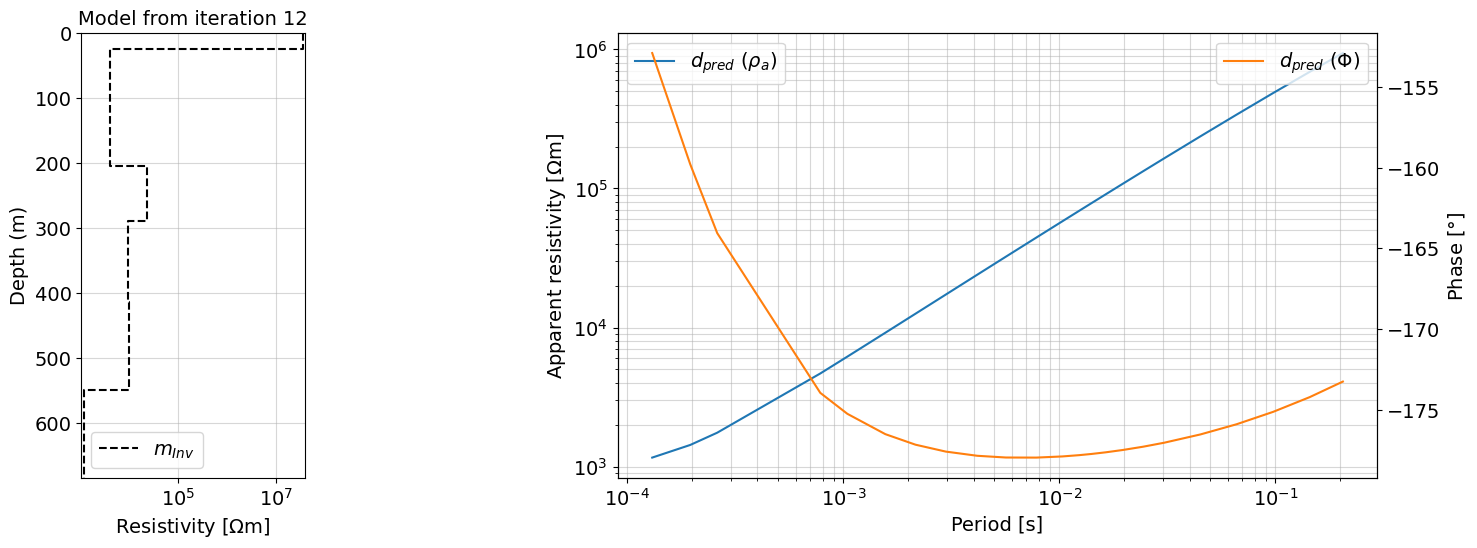

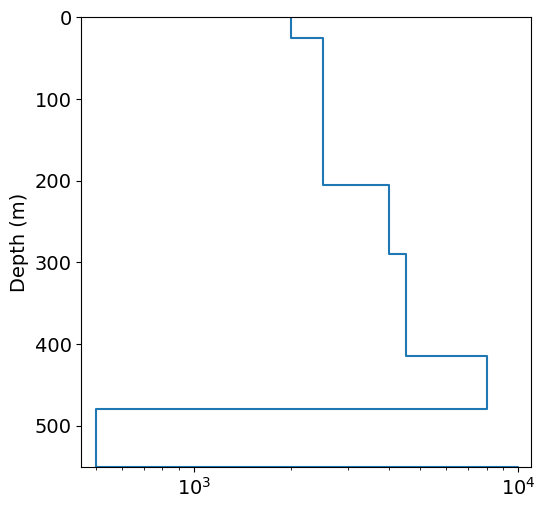

In [12]:
#Plotting
iteration = 12
dpred = output_dict[iteration]['dpred']
m = output_dict[iteration]['m']
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 5, figure=fig)

ax0 = fig.add_subplot(gs[0, 0])
plot_1d_layer_model(layer_thicknesses, 1/sigma) # figure has base value at log plot
plot_1d_layer_model(
    layer_thicknesses_inv,
    1.0 / np.exp(m),
    ax=ax0,
    color="k",
    label=r"$m_{Inv}$",
    linestyle="--",
)
ax0.legend()
ax0.set_xlabel(r"Resistivity [$\Omega$m]")
ax0.set_title('Model from iteration ' + str(iteration), fontsize=14)
ax0.grid(True, which='both', alpha=0.5)


ax = fig.add_subplot(gs[0, 2:])
ax.loglog(1./frequencies, dpred.reshape((len(frequencies), 2))[:,0], color='C0', label=r'$d_{pred}$ ($\rho_{a}$)')

ax_1 = ax.twinx()
ax_1.plot(1./frequencies, dpred.reshape((len(frequencies), 2))[:,1], color='C1', label=r'$d_{pred}$ ($\Phi$)')
ax.set_xlabel("Period [s]")
ax.grid(True, which='both', alpha=0.5)
ax.set_ylabel(r"Apparent resistivity [$\Omega$m]")
ax_1.set_ylabel(r"Phase [$\degree$]")
# ax.legend(bbox_to_anchor=(1.1,1))
ax.legend(loc=2)
ax_1.legend(loc=1)
plt.show()